In [ ]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt

# 1. Load Model
model_path = "models/det_10g.onnx"
session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])

# 2. Đọc ảnh test
img_path = "face.png" 
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.show()

In [ ]:
print(img_rgb.shape)

In [ ]:
input_size = (640, 640)
h, w = img_bgr.shape[:2]
ratio = min(input_size[0] / w, input_size[1] / h)
new_unpad = (int(round(w * ratio)), int(round(h * ratio)))

print(new_unpad)
print(ratio)

In [ ]:
img_resized = cv2.resize(img_bgr, new_unpad, interpolation=cv2.INTER_LINEAR)
dw = (input_size[0] - new_unpad[0]) // 2
dh = (input_size[1] - new_unpad[1]) // 2

print(dw, dh)

In [ ]:
# Tạo padding xám
blob_img = np.full((input_size[1], input_size[0], 3), 114, dtype=np.uint8)
blob_img[dh:dh + new_unpad[1], dw:dw + new_unpad[0]] = img_resized

# Normalize
blob = (blob_img.astype(np.float32) - 127.5) / 128.0
blob = np.transpose(blob, (2, 0, 1))
blob = np.expand_dims(blob, axis=0)

print(f"Shape đưa vào AI: {blob.shape}")
print(f"Giá trị pixel đầu tiên: {blob[0, 0, 0, 0]}") # Check xem có nằm trong khoảng [-1, 1] không

In [ ]:
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: blob})
print("Intput: ", session.get_inputs())
print("Output names:", [output.name for output in session.get_outputs()])
print(f"Tổng số mảng nhả ra: {len(outputs)}")

# In ra chi tiết từng mảng để phân tích
for i, out in enumerate(outputs):
    print(f"Output {i}: Name={session.get_outputs()[i].name}, Shape={out.shape}")

# Thử xem cái mảng Score đầu tiên (Stride 8)
scores_stride8 = outputs[0]
print(f"\nVí dụ 5 giá trị Score đầu tiên của Stride 8:\n{scores_stride8.flatten()[:5]}")

In [ ]:
print(outputs)

[1] Ảnh gốc kích thước: 1218x913
[3] Đã nhân Stride. Dữ liệu thô box xịn nhất (l,t,r,b): [ 72.02188 103.18035  74.74265  87.25265]
[5] Chốt Box trên ảnh gốc: xmin=350, ymin=108, xmax=629, ymax=470


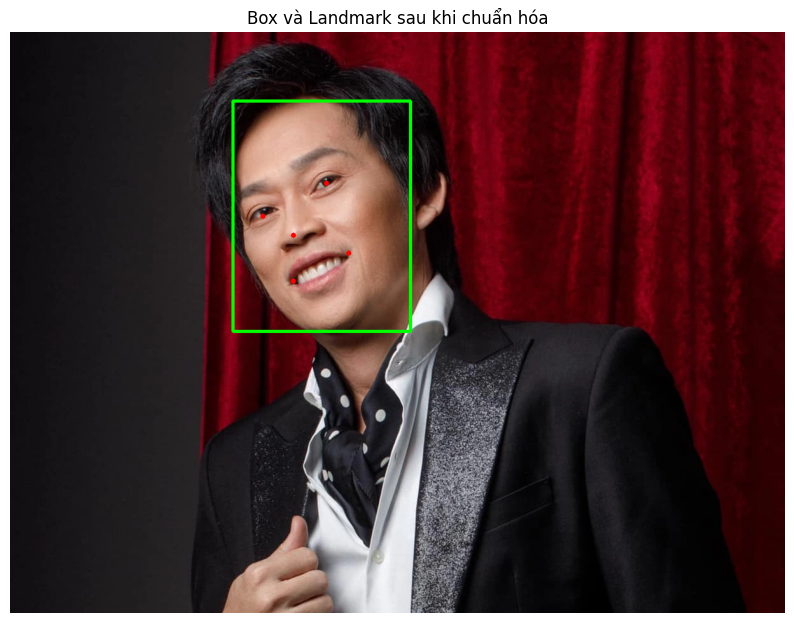

In [ ]:
# -*- coding: utf-8 -*-
# @Organization  : insightface.ai
# @Author        : Jia Guo
# @Time          : 2021-05-04
# @Function      : 

from __future__ import division
import datetime
import numpy as np
import onnx
import onnxruntime
import os
import os.path as osp
import cv2
import sys

def softmax(z):
    assert len(z.shape) == 2
    s = np.max(z, axis=1)
    s = s[:, np.newaxis] # necessary step to do broadcasting
    e_x = np.exp(z - s)
    div = np.sum(e_x, axis=1)
    div = div[:, np.newaxis] # dito
    return e_x / div

def distance2bbox(points, distance, max_shape=None):
    """Decode distance prediction to bounding box.

    Args:
        points (Tensor): Shape (n, 2), [x, y].
        distance (Tensor): Distance from the given point to 4
            boundaries (left, top, right, bottom).
        max_shape (tuple): Shape of the image.

    Returns:
        Tensor: Decoded bboxes.
    """
    x1 = points[:, 0] - distance[:, 0]
    y1 = points[:, 1] - distance[:, 1]
    x2 = points[:, 0] + distance[:, 2]
    y2 = points[:, 1] + distance[:, 3]
    if max_shape is not None:
        x1 = x1.clamp(min=0, max=max_shape[1])
        y1 = y1.clamp(min=0, max=max_shape[0])
        x2 = x2.clamp(min=0, max=max_shape[1])
        y2 = y2.clamp(min=0, max=max_shape[0])
    return np.stack([x1, y1, x2, y2], axis=-1)

def distance2kps(points, distance, max_shape=None):
    """Decode distance prediction to bounding box.

    Args:
        points (Tensor): Shape (n, 2), [x, y].
        distance (Tensor): Distance from the given point to 4
            boundaries (left, top, right, bottom).
        max_shape (tuple): Shape of the image.

    Returns:
        Tensor: Decoded bboxes.
    """
    preds = []
    for i in range(0, distance.shape[1], 2):
        px = points[:, i%2] + distance[:, i]
        py = points[:, i%2+1] + distance[:, i+1]
        if max_shape is not None:
            px = px.clamp(min=0, max=max_shape[1])
            py = py.clamp(min=0, max=max_shape[0])
        preds.append(px)
        preds.append(py)
    return np.stack(preds, axis=-1)

class SCRFD:
    def __init__(self, model_file=None, session=None):
        import onnxruntime
        self.model_file = model_file
        self.session = session
        self.taskname = 'detection'
        self.batched = False
        if self.session is None:
            assert self.model_file is not None
            assert osp.exists(self.model_file)
            self.session = onnxruntime.InferenceSession(self.model_file, None)
        self.center_cache = {}
        self.nms_thresh = 0.4
        self._init_vars()

    def _init_vars(self):
        input_cfg = self.session.get_inputs()[0]
        input_shape = input_cfg.shape
        if isinstance(input_shape[2], str):
            self.input_size = None
        else:
            self.input_size = tuple(input_shape[2:4][::-1])
        input_name = input_cfg.name
        outputs = self.session.get_outputs()
        if len(outputs[0].shape) == 3:
            self.batched = True
        output_names = []
        for o in outputs:
            output_names.append(o.name)
        self.input_name = input_name
        self.output_names = output_names
        self.use_kps = False
        self._num_anchors = 1
        if len(outputs)==6:
            self.fmc = 3
            self._feat_stride_fpn = [8, 16, 32]
            self._num_anchors = 2
        elif len(outputs)==9:
            self.fmc = 3
            self._feat_stride_fpn = [8, 16, 32]
            self._num_anchors = 2
            self.use_kps = True
        elif len(outputs)==10:
            self.fmc = 5
            self._feat_stride_fpn = [8, 16, 32, 64, 128]
            self._num_anchors = 1
        elif len(outputs)==15:
            self.fmc = 5
            self._feat_stride_fpn = [8, 16, 32, 64, 128]
            self._num_anchors = 1
            self.use_kps = True

    def prepare(self, ctx_id, **kwargs):
        if ctx_id<0:
            self.session.set_providers(['CPUExecutionProvider'])
        nms_thresh = kwargs.get('nms_thresh', None)
        if nms_thresh is not None:
            self.nms_thresh = nms_thresh
        input_size = kwargs.get('input_size', None)
        if input_size is not None:
            if self.input_size is not None:
                print('warning: det_size is already set in scrfd model, ignore')
            else:
                self.input_size = input_size

    def forward(self, img, thresh):
        scores_list = []
        bboxes_list = []
        kpss_list = []
        input_size = tuple(img.shape[0:2][::-1])
        blob = cv2.dnn.blobFromImage(img, 1.0/128, input_size, (127.5, 127.5, 127.5), swapRB=True)
        net_outs = self.session.run(self.output_names, {self.input_name : blob})

        input_height = blob.shape[2]
        input_width = blob.shape[3]
        fmc = self.fmc
        for idx, stride in enumerate(self._feat_stride_fpn):
            # If model support batch dim, take first output
            if self.batched:
                scores = net_outs[idx][0]
                bbox_preds = net_outs[idx + fmc][0]
                bbox_preds = bbox_preds * stride
                if self.use_kps:
                    kps_preds = net_outs[idx + fmc * 2][0] * stride
            # If model doesn't support batching take output as is
            else:
                scores = net_outs[idx]
                bbox_preds = net_outs[idx + fmc]
                bbox_preds = bbox_preds * stride
                if self.use_kps:
                    kps_preds = net_outs[idx + fmc * 2] * stride

            height = input_height // stride
            width = input_width // stride
            K = height * width
            key = (height, width, stride)
            if key in self.center_cache:
                anchor_centers = self.center_cache[key]
            else:
                #solution-1, c style:
                #anchor_centers = np.zeros( (height, width, 2), dtype=np.float32 )
                #for i in range(height):
                #    anchor_centers[i, :, 1] = i
                #for i in range(width):
                #    anchor_centers[:, i, 0] = i

                #solution-2:
                #ax = np.arange(width, dtype=np.float32)
                #ay = np.arange(height, dtype=np.float32)
                #xv, yv = np.meshgrid(np.arange(width), np.arange(height))
                #anchor_centers = np.stack([xv, yv], axis=-1).astype(np.float32)

                #solution-3:
                anchor_centers = np.stack(np.mgrid[:height, :width][::-1], axis=-1).astype(np.float32)
                #print(anchor_centers.shape)

                anchor_centers = (anchor_centers * stride).reshape( (-1, 2) )
                if self._num_anchors>1:
                    anchor_centers = np.stack([anchor_centers]*self._num_anchors, axis=1).reshape( (-1,2) )
                if len(self.center_cache)<100:
                    self.center_cache[key] = anchor_centers

            pos_inds = np.where(scores>=thresh)[0]
            bboxes = distance2bbox(anchor_centers, bbox_preds)
            pos_scores = scores[pos_inds]
            pos_bboxes = bboxes[pos_inds]
            scores_list.append(pos_scores)
            bboxes_list.append(pos_bboxes)
            if self.use_kps:
                kpss = distance2kps(anchor_centers, kps_preds)
                #kpss = kps_preds
                kpss = kpss.reshape( (kpss.shape[0], -1, 2) )
                pos_kpss = kpss[pos_inds]
                kpss_list.append(pos_kpss)
        return scores_list, bboxes_list, kpss_list

    def detect(self, img, thresh=0.5, input_size = None, max_num=0, metric='default'):
        assert input_size is not None or self.input_size is not None
        input_size = self.input_size if input_size is None else input_size
            
        im_ratio = float(img.shape[0]) / img.shape[1]
        model_ratio = float(input_size[1]) / input_size[0]
        if im_ratio>model_ratio:
            new_height = input_size[1]
            new_width = int(new_height / im_ratio)
        else:
            new_width = input_size[0]
            new_height = int(new_width * im_ratio)
        det_scale = float(new_height) / img.shape[0]
        resized_img = cv2.resize(img, (new_width, new_height))
        det_img = np.zeros( (input_size[1], input_size[0], 3), dtype=np.uint8 )
        det_img[:new_height, :new_width, :] = resized_img

        scores_list, bboxes_list, kpss_list = self.forward(det_img, thresh)

        scores = np.vstack(scores_list)
        scores_ravel = scores.ravel()
        order = scores_ravel.argsort()[::-1]
        bboxes = np.vstack(bboxes_list) / det_scale
        if self.use_kps:
            kpss = np.vstack(kpss_list) / det_scale
        pre_det = np.hstack((bboxes, scores)).astype(np.float32, copy=False)
        pre_det = pre_det[order, :]
        keep = self.nms(pre_det)
        det = pre_det[keep, :]
        if self.use_kps:
            kpss = kpss[order,:,:]
            kpss = kpss[keep,:,:]
        else:
            kpss = None
        if max_num > 0 and det.shape[0] > max_num:
            area = (det[:, 2] - det[:, 0]) * (det[:, 3] -
                                                    det[:, 1])
            img_center = img.shape[0] // 2, img.shape[1] // 2
            offsets = np.vstack([
                (det[:, 0] + det[:, 2]) / 2 - img_center[1],
                (det[:, 1] + det[:, 3]) / 2 - img_center[0]
            ])
            offset_dist_squared = np.sum(np.power(offsets, 2.0), 0)
            if metric=='max':
                values = area
            else:
                values = area - offset_dist_squared * 2.0  # some extra weight on the centering
            bindex = np.argsort(
                values)[::-1]  # some extra weight on the centering
            bindex = bindex[0:max_num]
            det = det[bindex, :]
            if kpss is not None:
                kpss = kpss[bindex, :]
        return det, kpss

    def nms(self, dets):
        thresh = self.nms_thresh
        x1 = dets[:, 0]
        y1 = dets[:, 1]
        x2 = dets[:, 2]
        y2 = dets[:, 3]
        scores = dets[:, 4]

        areas = (x2 - x1 + 1) * (y2 - y1 + 1)
        order = scores.argsort()[::-1]

        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])

            w = np.maximum(0.0, xx2 - xx1 + 1)
            h = np.maximum(0.0, yy2 - yy1 + 1)
            inter = w * h
            ovr = inter / (areas[i] + areas[order[1:]] - inter)

            inds = np.where(ovr <= thresh)[0]
            order = order[inds + 1]

        return keep

def get_scrfd(name, download=False, root='~/.insightface/models', **kwargs):
    if not download:
        assert os.path.exists(name)
        return SCRFD(name)
    else:
        from .model_store import get_model_file
        _file = get_model_file("scrfd_%s" % name, root=root)
        return SCRFD(_file)


def scrfd_2p5gkps(**kwargs):
    return get_scrfd("2p5gkps", download=True, **kwargs)


if __name__ == '__main__':
    import glob
    #detector = SCRFD(model_file='./det.onnx')
    detector = SCRFD(model_file='./models/det_10g.onnx')
    detector.prepare(-1)
    img_paths = ['face.png', 'face2.png']
    for img_path in img_paths:
        img = cv2.imread(img_path)

        for _ in range(1):
            ta = datetime.datetime.now()
            bboxes, kpss = detector.detect(img, 0.5, input_size = (640, 640))
            #bboxes, kpss = detector.detect(img, 0.5)
            tb = datetime.datetime.now()
            print('all cost:', (tb-ta).total_seconds()*1000)
        print(img_path, bboxes.shape)
        if kpss is not None:
            print(kpss.shape)
        for i in range(bboxes.shape[0]):
            bbox = bboxes[i]
            x1,y1,x2,y2,score = bbox.astype(np.int)
            cv2.rectangle(img, (x1,y1)  , (x2,y2) , (255,0,0) , 2)
            if kpss is not None:
                kps = kpss[i]
                for kp in kps:
                    kp = kp.astype(np.int)
                    cv2.circle(img, tuple(kp) , 1, (0,0,255) , 2)
        filename = img_path.split('/')[-1]
        print('output:', filename)
        cv2.imwrite('./outputs/%s'%filename, img)